In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
df = pd.read_csv("AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [4]:
df.select_dtypes(include=[np.number]).corr()["SalePrice"].sort_values(ascending=False)


SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647877
Garage Area        0.640401
Total Bsmt SF      0.632280
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Garage Yr Blt      0.526965
Mas Vnr Area       0.508285
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.432914
Lot Frontage       0.357318
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.276050
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.182855
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.005891
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035835
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0

In [5]:
selected_features = [
    "Overall Qual", "Gr Liv Area", "Garage Cars", 
    "Garage Area", "Total Bsmt SF", "1st Flr SF",
    "Year Built", "Full Bath", "Year Remod/Add"
]

In [6]:
df_selected = df[selected_features + ["SalePrice"]]
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Overall Qual    2930 non-null   int64  
 1   Gr Liv Area     2930 non-null   int64  
 2   Garage Cars     2929 non-null   float64
 3   Garage Area     2929 non-null   float64
 4   Total Bsmt SF   2929 non-null   float64
 5   1st Flr SF      2930 non-null   int64  
 6   Year Built      2930 non-null   int64  
 7   Full Bath       2930 non-null   int64  
 8   Year Remod/Add  2930 non-null   int64  
 9   SalePrice       2930 non-null   int64  
dtypes: float64(3), int64(7)
memory usage: 229.0 KB


In [7]:
df_selected.head()

,Overall Qual,Gr Liv Area,Garage Cars,Garage Area,Total Bsmt SF,1st Flr SF,Year Built,Full Bath,Year Remod/Add,SalePrice
0,6,1656,2.0,528.0,1080.0,1656,1960,1,1960,215000
1,5,896,1.0,730.0,882.0,896,1961,1,1961,105000
2,6,1329,1.0,312.0,1329.0,1329,1958,1,1958,172000
3,7,2110,2.0,522.0,2110.0,2110,1968,2,1968,244000
4,5,1629,2.0,482.0,928.0,928,1997,2,1998,189900


array([[<Axes: title={'center': 'Overall Qual'}>,
        <Axes: title={'center': 'Gr Liv Area'}>,
        <Axes: title={'center': 'Garage Cars'}>],
       [<Axes: title={'center': 'Garage Area'}>,
        <Axes: title={'center': 'Total Bsmt SF'}>,
        <Axes: title={'center': '1st Flr SF'}>],
       [<Axes: title={'center': 'Year Built'}>,
        <Axes: title={'center': 'Full Bath'}>,
        <Axes: title={'center': 'Year Remod/Add'}>],
       [<Axes: title={'center': 'SalePrice'}>, <Axes: >, <Axes: >]],
      dtype=object)

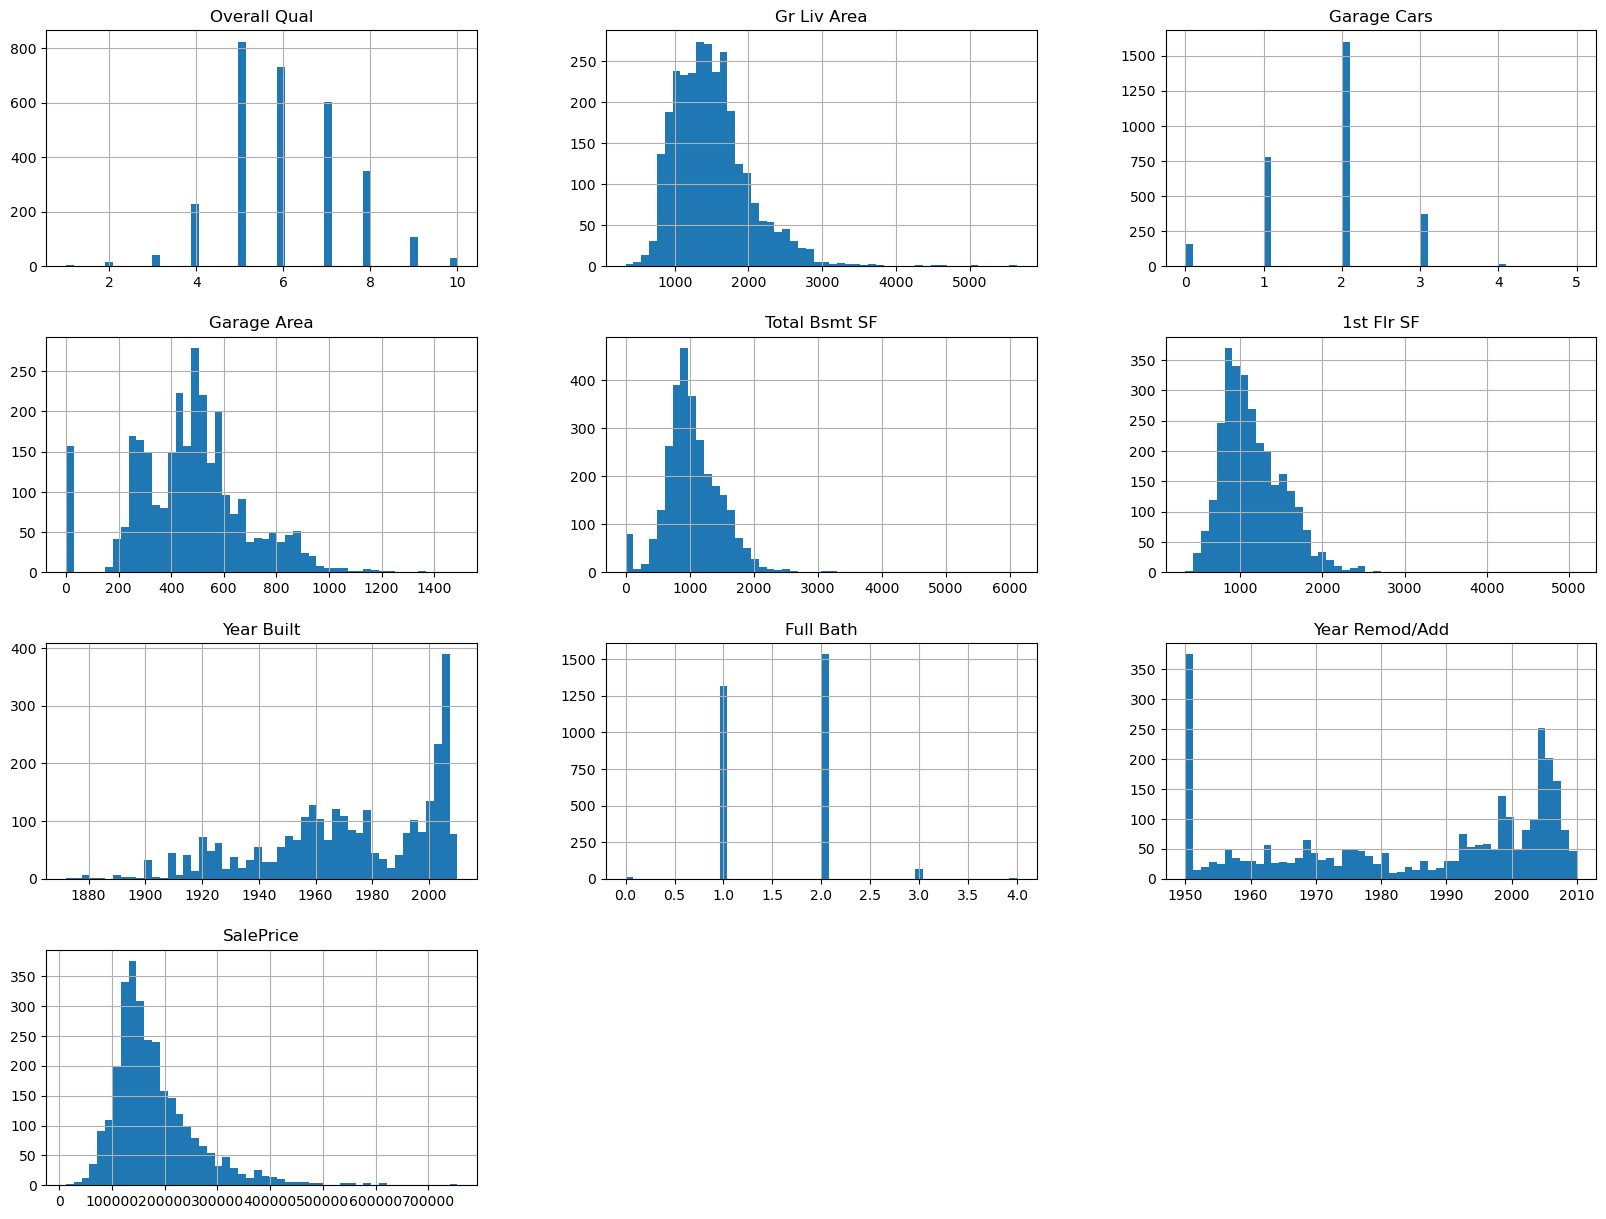

In [8]:
df_selected.hist(bins=50, figsize=(20,15))

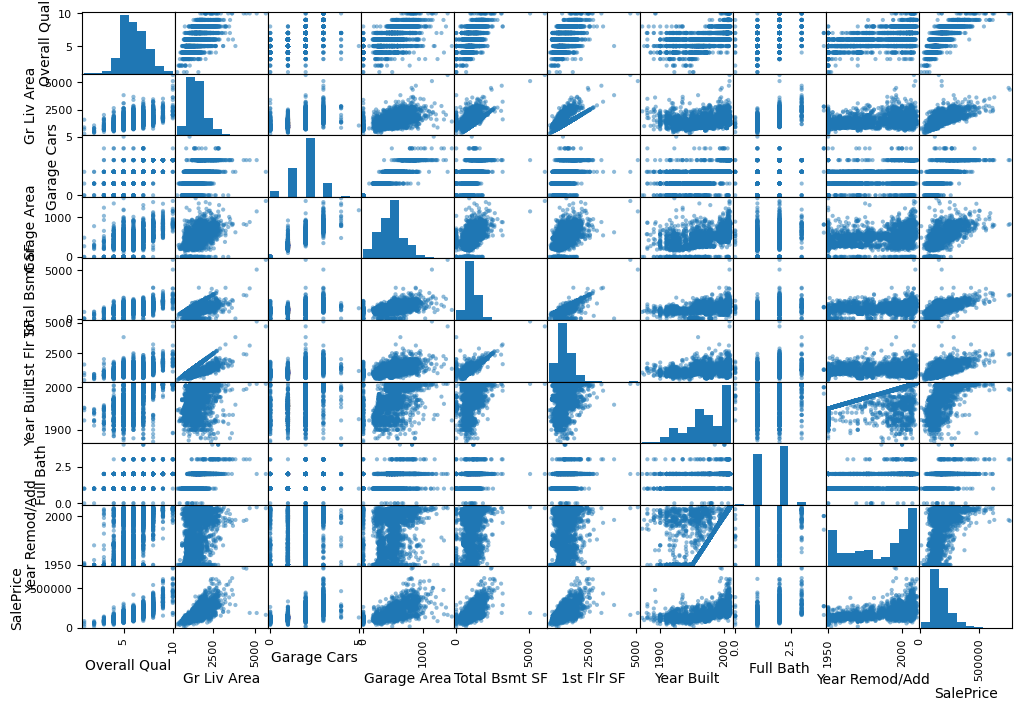

In [9]:
from pandas.plotting import scatter_matrix

scatter_matrix(df_selected,figsize=(12,8))

plt.show()

In [10]:
from sklearn.model_selection import train_test_split

X = df_selected.drop("SalePrice", axis=1)
y = df_selected["SalePrice"]

df_selected["price_cat"] = pd.cut(df_selected["SalePrice"],
    bins=[0, 100000, 150000, 200000, 250000, np.inf],
    labels=[1, 2, 3, 4, 5])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=df_selected["price_cat"], random_state=42)

/tmp/ipykernel_5595/1639668498.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected["price_cat"] = pd.cut(df_selected["SalePrice"],


In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

preprocessing = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)


In [12]:
preprocessing.fit(X_train)

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [13]:
X_train_prepared = preprocessing.transform(X_train)
X_test_prepared = preprocessing.transform(X_test)

In [14]:
from sklearn.linear_model import LinearRegression

linear_reg = LinearRegression()

linear_reg.fit(X_train_prepared,y_train)

predictions = linear_reg.predict(X_train_prepared)

In [15]:
from sklearn.metrics import root_mean_squared_error

scores = root_mean_squared_error(y_train, predictions)



In [16]:
scores

36376.48118217878

In [17]:
from sklearn.metrics import mean_absolute_error
scores2 = mean_absolute_error(y_train,predictions)

In [18]:
scores2

23323.73740902713

In [19]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(linear_reg, X_train_prepared, y_train,
                         scoring="neg_root_mean_squared_error", cv=10)
print(f"Mean RMSE: {-scores.mean():,.0f}")
print(f"Std: {scores.std():,.0f}")

Mean RMSE: 36,248
Std: 8,062


In [ ]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_train_prepared, y_train)
predictions_forest = forest_reg.predict(X_train_prepared)
scores_forest = root_mean_squared_error(y_train, predictions_forest)

scores_forest_cv = cross_val_score(forest_reg, X_train_prepared, y_train,
                         scoring="neg_root_mean_squared_error", cv=10)
print(f"Mean RMSE: {-scores_forest_cv.mean():,.0f}")
print(f"Std: {scores_forest_cv.std():,.0f}")


Mean RMSE: 29,495
Std: 5,548


In [21]:
from sklearn.model_selection import GridSearchCV
param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
]
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(X_train_prepared, y_train)  
grid_search.best_params_

{'max_features': 4, 'n_estimators': 30}

In [22]:
final_model = grid_search.best_estimator_
final_predictions = final_model.predict(X_test_prepared)
final_scores = root_mean_squared_error(y_test, final_predictions)
final_scores    


26398.884982236414